# 💰 Notebook 4: Tariff Pricing Agent
**Project**: Agentic AI-Based Dynamic Tariff Optimization for EV Charging Networks  
**Team**: Socbiz Analytics | OP'26  

---

## Overview
The Tariff Pricing Agent translates demand predictions into optimal per-kWh tariffs using a rule-based surge/discount logic informed by price elasticity of demand.

### Pricing Rules
| Condition | Action |
|-----------|--------|
| Predicted utilisation ≥ 80% | Surge up to **1.5×** base tariff |
| Predicted utilisation ≤ 30% | **30% discount** (0.70×) |
| 30% < utilisation < 80% | Linear interpolation between discount and base |

### Assumptions (documented)
- **Base tariff**: ₹15/kWh (India fixed-rate baseline)
- **Price elasticity**: −0.3 (a 10% price rise → 3% demand fall)
- Surge scales linearly from 1.0× at 80% to 1.5× at 100% utilisation
- Off-peak flat discount: 0.70× to attract demand into low-utilisation windows


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os, warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

BASE_DIR    = "/Users/saksham56/Desktop/open-projects/Socbiz Analytics Project"
RESULTS_DIR = os.path.join(BASE_DIR, "outputs", "results")

print("── Tariff Pricing Agent ──")
pred_path = os.path.join(RESULTS_DIR, "demand_predictions.csv")
df = pd.read_csv(pred_path)
df['datetime'] = pd.to_datetime(df['datetime'])
print(f"Loaded demand predictions: {df.shape}")
print(df.head(3))


── Tariff Pricing Agent ──
Loaded demand predictions: (426322, 6)
             datetime  grid_id  actual_utilization  energy_kwh  \
0 2022-07-13 00:10:00      102            0.633333    4.958333   
1 2022-07-13 00:15:00      102            0.633333    4.958333   
2 2022-07-13 00:20:00      102            0.633333    4.958333   

   predicted_utilization  congestion_probability  
0               0.633714            7.604509e-07  
1               0.633714            7.604509e-07  
2               0.633714            7.604509e-07  


## Dynamic Tariff Calculation

In [2]:
BASE_TARIFF  = 15.0   # ₹/kWh
ELASTICITY   = -0.3   # demand elasticity

def dynamic_tariff(util, base=BASE_TARIFF):
    """
    Rule-based surge/discount tariff.
    ASSUMPTION: Surge multiplier scales linearly 1.0→1.5 for util in [0.80, 1.00].
    ASSUMPTION: Discount is flat 0.70× for util ≤ 0.30.
    ASSUMPTION: Linear interpolation in transition zone [0.30, 0.80].
    """
    if util >= 0.80:
        mult = 1.0 + 0.5 * ((util - 0.80) / 0.20)
        mult = min(mult, 1.50)
    elif util <= 0.30:
        mult = 0.70
    else:
        mult = 0.70 + 0.30 * ((util - 0.30) / 0.50)
    return round(base * mult, 2)

df['fixed_tariff']   = BASE_TARIFF
df['dynamic_tariff'] = df['predicted_utilization'].apply(dynamic_tariff)

# Demand shift via elasticity
df['price_change_pct']     = (df['dynamic_tariff'] - BASE_TARIFF) / BASE_TARIFF
df['demand_change_pct']    = df['price_change_pct'] * ELASTICITY
df['simulated_energy_kwh'] = np.maximum(0.0, df['energy_kwh'] * (1 + df['demand_change_pct']))
df['simulated_utilization']= np.clip(df['actual_utilization'] * (1 + df['demand_change_pct']), 0, 1)

# Revenue
df['fixed_revenue']   = BASE_TARIFF * df['energy_kwh']
df['dynamic_revenue'] = df['dynamic_tariff'] * df['simulated_energy_kwh']

print("Dynamic tariffs calculated. Sample:")
print(df[['datetime','predicted_utilization','fixed_tariff','dynamic_tariff',
          'simulated_energy_kwh','dynamic_revenue']].head(5).to_string(index=False))


Dynamic tariffs calculated. Sample:
           datetime  predicted_utilization  fixed_tariff  dynamic_tariff  simulated_energy_kwh  dynamic_revenue
2022-07-13 00:10:00               0.633714          15.0            13.5              5.107083        68.945625
2022-07-13 00:15:00               0.633714          15.0            13.5              5.107083        68.945625
2022-07-13 00:20:00               0.633714          15.0            13.5              5.107083        68.945625
2022-07-13 00:25:00               0.633714          15.0            13.5              5.107083        68.945625
2022-07-13 00:30:00               0.633714          15.0            13.5              5.107083        68.945625


## KPI Calculation — Revenue, Utilisation & Off-Peak Uplift

In [3]:
total_fixed_rev   = df['fixed_revenue'].sum()
total_dynamic_rev = df['dynamic_revenue'].sum()
revenue_gain_pct  = (total_dynamic_rev - total_fixed_rev) / total_fixed_rev * 100

mean_util_before  = df['actual_utilization'].mean()
mean_util_after   = df['simulated_utilization'].mean()

off_peak_mask          = df['actual_utilization'] < 0.30
off_peak_before        = df.loc[off_peak_mask, 'energy_kwh'].sum()
off_peak_after         = df.loc[off_peak_mask, 'simulated_energy_kwh'].sum()
off_peak_uplift_pct    = (off_peak_after - off_peak_before) / off_peak_before * 100 if off_peak_before > 0 else 0.0

print("="*55)
print("  TARIFF PRICING AGENT — KPI RESULTS")
print("="*55)
print(f"  Base tariff            : ₹{BASE_TARIFF}/kWh")
print(f"  Total Fixed Revenue    : ₹{total_fixed_rev:>15,.0f}")
print(f"  Total Dynamic Revenue  : ₹{total_dynamic_rev:>15,.0f}")
print(f"  Revenue Gain %         : {revenue_gain_pct:>10.2f}%")
print(f"  Mean Util Before       : {mean_util_before*100:>10.2f}%")
print(f"  Mean Util After        : {mean_util_after*100:>10.2f}%")
print(f"  Off-Peak Energy Uplift : {off_peak_uplift_pct:>10.2f}%")
print("="*55)


  TARIFF PRICING AGENT — KPI RESULTS
  Base tariff            : ₹15.0/kWh
  Total Fixed Revenue    : ₹    259,849,196
  Total Dynamic Revenue  : ₹    222,660,993
  Revenue Gain %         :     -14.31%
  Mean Util Before       :      29.09%
  Mean Util After        :      30.99%
  Off-Peak Energy Uplift :       9.00%


## Figure — Tariff Distribution by Utilisation Zone

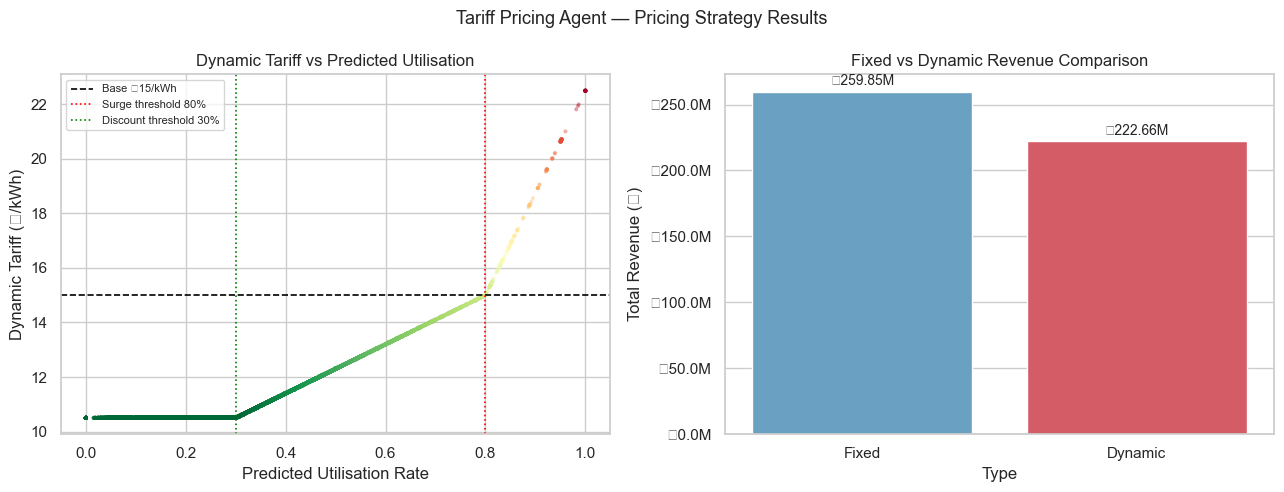

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: Tariff vs Utilisation (scatterplot)
sample = df.sample(n=min(20000, len(df)), random_state=42)
axes[0].scatter(sample['predicted_utilization'], sample['dynamic_tariff'],
                c=sample['dynamic_tariff'], cmap='RdYlGn_r', alpha=0.3, s=4, rasterized=True)
axes[0].axhline(BASE_TARIFF, color='black', linestyle='--', linewidth=1.2, label='Base ₹15/kWh')
axes[0].axvline(0.80, color='red',   linestyle=':', linewidth=1.2, label='Surge threshold 80%')
axes[0].axvline(0.30, color='green', linestyle=':', linewidth=1.2, label='Discount threshold 30%')
axes[0].set_title('Dynamic Tariff vs Predicted Utilisation')
axes[0].set_xlabel('Predicted Utilisation Rate')
axes[0].set_ylabel('Dynamic Tariff (₹/kWh)')
axes[0].legend(fontsize=8)

# Right: Revenue comparison bar
rev_data = pd.DataFrame({'Type':['Fixed','Dynamic'],
                          'Revenue':[total_fixed_rev, total_dynamic_rev]})
bars = sns.barplot(data=rev_data, x='Type', y='Revenue',
                   palette=['#5BA4CF','#E84855'], ax=axes[1])
axes[1].set_title('Fixed vs Dynamic Revenue Comparison')
axes[1].set_ylabel('Total Revenue (₹)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{x/1e6:.1f}M'))
for bar, val in zip(bars.patches, rev_data['Revenue']):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
                 f'₹{val/1e6:.2f}M', ha='center', va='bottom', fontsize=10)

plt.suptitle('Tariff Pricing Agent — Pricing Strategy Results', fontsize=13)
plt.tight_layout()
plt.show()


## Figure — Utilisation Shift (Before vs After Dynamic Pricing)

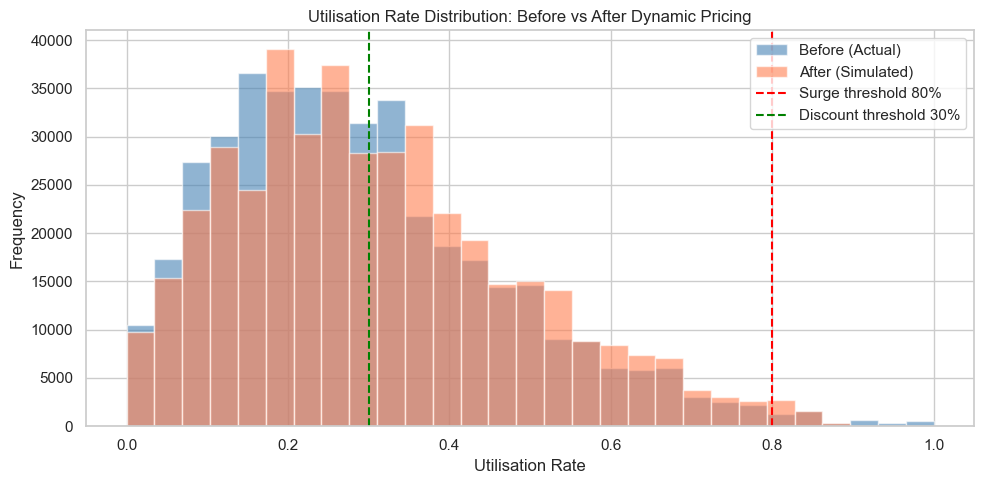

Insight: Dynamic pricing shifts demand away from peak (>80%) into mid-range zones.
Simulated mean utilisation: 30.99%  (vs 29.09% baseline)


In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
bins = np.linspace(0, 1, 30)
ax.hist(df['actual_utilization'],    bins=bins, alpha=0.6, label='Before (Actual)', color='steelblue')
ax.hist(df['simulated_utilization'], bins=bins, alpha=0.6, label='After (Simulated)', color='coral')
ax.axvline(0.80, color='red',   linestyle='--', linewidth=1.5, label='Surge threshold 80%')
ax.axvline(0.30, color='green', linestyle='--', linewidth=1.5, label='Discount threshold 30%')
ax.set_title('Utilisation Rate Distribution: Before vs After Dynamic Pricing')
ax.set_xlabel('Utilisation Rate')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Insight: Dynamic pricing shifts demand away from peak (>80%) into mid-range zones.")
print(f"Simulated mean utilisation: {mean_util_after:.2%}  (vs {mean_util_before:.2%} baseline)")


## Figure — Hourly Average Dynamic Tariff by Time-of-Day

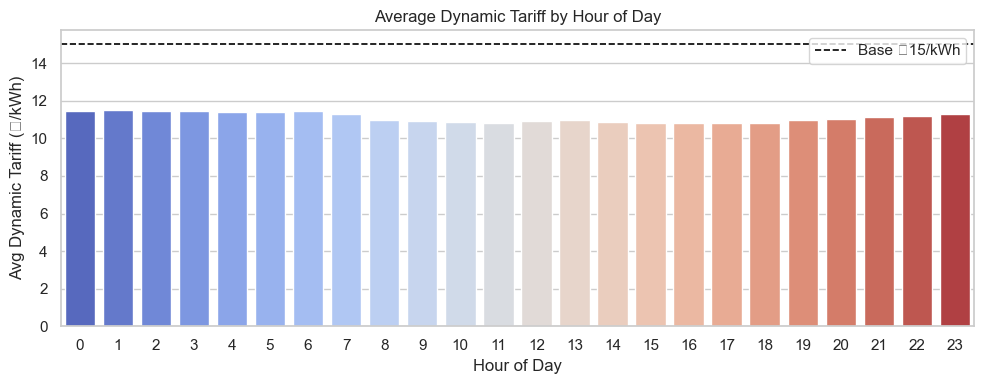

In [6]:
df['hour'] = df['datetime'].dt.hour
hourly_tariff = df.groupby('hour')['dynamic_tariff'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=hourly_tariff, x='hour', y='dynamic_tariff',
            palette='coolwarm', ax=ax)
ax.axhline(BASE_TARIFF, color='black', linestyle='--', linewidth=1.2, label='Base ₹15/kWh')
ax.set_title('Average Dynamic Tariff by Hour of Day')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Avg Dynamic Tariff (₹/kWh)')
ax.legend()
plt.tight_layout()
plt.show()


In [7]:
# Save results
out_path = os.path.join(RESULTS_DIR, "dynamic_tariffs.csv")
df.to_csv(out_path, index=False)
print(f"✓ Dynamic tariffs saved → {out_path}  shape={df.shape}")
print("\n✓ Tariff Pricing Agent completed.")


✓ Dynamic tariffs saved → /Users/saksham56/Desktop/open-projects/Socbiz Analytics Project/outputs/results/dynamic_tariffs.csv  shape=(426322, 15)

✓ Tariff Pricing Agent completed.
